# Deutsch-Jozsa
One query decides whether an oracle $f:\{0,1\}^n\!\to\!\{0,1\}$ is **constant** or **balanced**.
Measure the $n$-qubit input register: all-zeros $\Rightarrow$ constant, anything else $\Rightarrow$ balanced.
Here we run the same circuit on the real backend and on a noise-matched simulator, in parallel.

In [15]:
# Connect to IBM Quantum (account already saved from the parallelism notebook)
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

In [16]:
# Pick the real backend and build a Sampler bound to it
from qiskit_ibm_runtime import SamplerV2 as Sampler

backend = service.backend("ibm_marrakesh")
sampler = Sampler(mode=backend)
print(backend.name)

ibm_marrakesh


In [17]:
# Build a local Aer simulator that mimics the backend's noise
from qiskit.primitives import BackendSamplerV2
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

noise_model = NoiseModel.from_backend(backend)
backend_sim = AerSimulator(noise_model=noise_model)
sampler_sim = BackendSamplerV2(backend=backend_sim)

In [18]:
# Oracle: 'constant' does nothing to the target; 'balanced' CXs every input into it
from qiskit import QuantumCircuit

def dj_oracle(n: int, kind: str) -> QuantumCircuit:
    oracle = QuantumCircuit(n + 1)
    if kind == "balanced":
        for q in range(n):
            oracle.cx(q, n)
    elif kind != "constant":
        raise ValueError("kind must be 'constant' or 'balanced'")
    return oracle

#number of qubits+1
n = 5

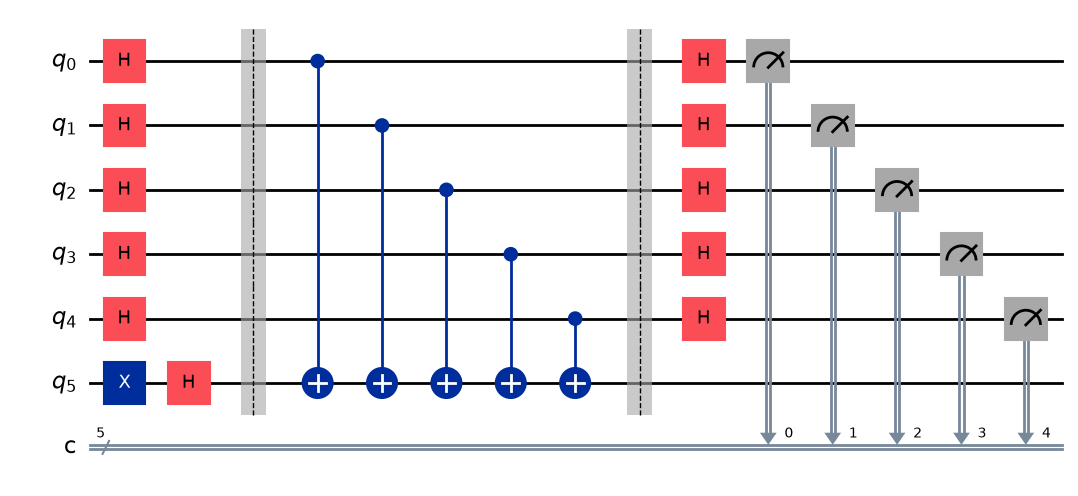

In [19]:
# Assemble the full Deutsch-Jozsa circuit and draw it
kind = "balanced"   # try "constant" too

qc = QuantumCircuit(n + 1, n)
qc.x(n)                       # target starts in |1>
qc.h(range(n + 1))            # superposition + |-> on target
qc.barrier()
qc.compose(dj_oracle(n, kind), inplace=True)
qc.barrier()
qc.h(range(n))               # interference on the input register
qc.measure(range(n), range(n))

qc.draw("mpl")

In [20]:
# Transpile to the backend's native gates/qubits (ISA circuit)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(target=backend.target, optimization_level=3)
qc_isa = pm.run(qc)

In [21]:
# Submit both jobs first so they run in parallel, then collect results
job_real = sampler.run([qc_isa], shots=1024)
job_sim = sampler_sim.run([qc_isa], shots=1024)

counts_real = job_real.result()[0].data.c.get_counts()
counts_sim = job_sim.result()[0].data.c.get_counts()

real most frequent: 11111
sim  most frequent: 11111


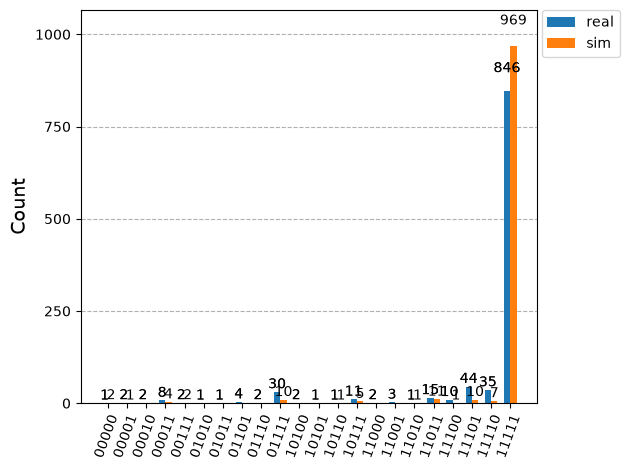

In [22]:
# Compare the two histograms; all-zeros = constant, else = balanced
from qiskit.visualization import plot_histogram

print("real most frequent:", max(counts_real, key=counts_real.get))
print("sim  most frequent:", max(counts_sim, key=counts_sim.get))
plot_histogram([counts_real, counts_sim], legend=["real", "sim"])

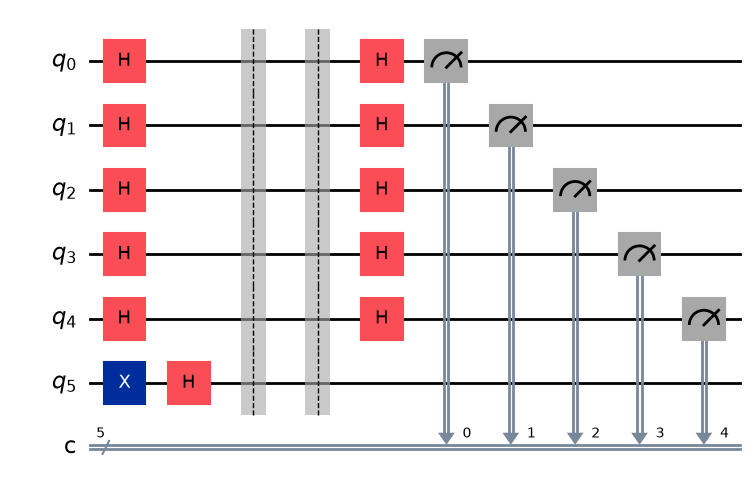

In [23]:
# Assemble the full Deutsch-Jozsa circuit and draw it
kind = "constant"   # try "constant" too

qc = QuantumCircuit(n + 1, n)
qc.x(n)                       # target starts in |1>
qc.h(range(n + 1))            # superposition + |-> on target
qc.barrier()
qc.compose(dj_oracle(n, kind), inplace=True)
qc.barrier()
qc.h(range(n))               # interference on the input register
qc.measure(range(n), range(n))

qc.draw("mpl")

In [24]:
# Transpile to the backend's native gates/qubits (ISA circuit)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(target=backend.target, optimization_level=3)
qc_isa = pm.run(qc)

In [25]:
# Submit both jobs first so they run in parallel, then collect results
job_real = sampler.run([qc_isa], shots=1024)
job_sim = sampler_sim.run([qc_isa], shots=1024)

counts_real = job_real.result()[0].data.c.get_counts()
counts_sim = job_sim.result()[0].data.c.get_counts()

real most frequent: 00000
sim  most frequent: 00000


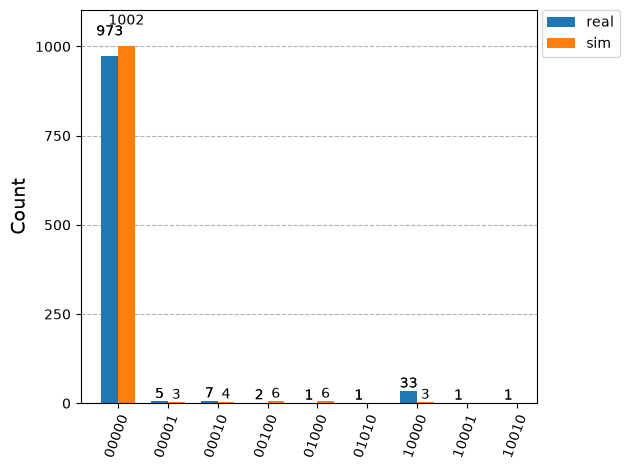

In [26]:
# Compare the two histograms; all-zeros = constant, else = balanced
from qiskit.visualization import plot_histogram

print("real most frequent:", max(counts_real, key=counts_real.get))
print("sim  most frequent:", max(counts_sim, key=counts_sim.get))
plot_histogram([counts_real, counts_sim], legend=["real", "sim"])